In [1]:
import pandas as pd
  
# makes the passed rows header
data = pd.read_csv("laplace.csv", header =[0])

In [2]:
data

,x,y,u
0,0.00,0.0,0.00
1,0.01,0.0,0.01
2,0.02,0.0,0.02
3,0.03,0.0,0.03
4,0.04,0.0,0.04
...,...,...,...
10196,0.96,1.0,0.96
10197,0.97,1.0,0.97
10198,0.98,1.0,0.98
10199,0.99,1.0,0.99


In [3]:
import numpy as np
converted = np.array(data)

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(converted[:,0:2], converted[:,2], test_size=0.33, random_state=42)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
# Keras :
from keras import backend as K
import tensorflow as tf
import keras 
from keras.layers import Input, Dense, add, Activation, Reshape , Conv1D, Flatten ,GlobalAveragePooling1D , Lambda, Dropout, concatenate
from keras.models import Model, model_from_json, model_from_yaml
from keras import optimizers 
from keras.callbacks import CSVLogger
from keras.losses import mse
from keras.utils.generic_utils import get_custom_objects

In [6]:

# optimizer (NAdam) parameters
lr = 0.005       # learning rate
beta_1=0.9       # beta 1
beta_2=0.999     # beta 2

In [7]:

class EarlyStoppingAtMinLoss(tf.keras.callbacks.Callback):
  """Stop training when the loss is at its min, i.e. the loss stops decreasing.

  Arguments:
      patience: Number of epochs to wait after min has been hit. After this
      number of no improvement, training stops.
  """

  def __init__(self, patience=20):
    super(EarlyStoppingAtMinLoss, self).__init__()

    self.patience = patience

    # best_weights to store the weights at which the minimum loss occurs.
    self.best_weights = None

  def on_train_begin(self, logs=None):
    # The number of epoch it has waited when loss is no longer minimum.
    self.wait = 0
    # The epoch the training stops at.
    self.stopped_epoch = 0
    # Initialize the best as infinity.
    self.best = np.Inf

  def on_epoch_end(self, epoch, logs=None):
    current = logs.get('loss')
    if np.less(current, self.best):
      self.best = current
      self.wait = 0
      # Record the best weights if current results is better (less).
      self.best_weights = self.model.get_weights()
    else:
      self.wait += 1
      if self.wait >= self.patience:
        self.stopped_epoch = epoch
        self.model.stop_training = True
        print('Restoring model weights from the end of the best epoch.')
        self.model.set_weights(self.best_weights)

  def on_train_end(self, logs=None):
    if self.stopped_epoch > 0:
      print('Epoch %05d: early stopping' % (self.stopped_epoch + 1))

In [8]:
x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
merged = keras.layers.Concatenate(axis=1)([x, y])
dense1 = keras.layers.Dense(2, input_dim=2, activation=keras.activations.sigmoid, use_bias=True)(merged)
u = keras.layers.Dense(1, activation=keras.activations.relu, use_bias=True)(dense1)
model = keras.models.Model(inputs=[x, y], outputs=u)

In [9]:
x = tf.keras.Input(shape=(1, ))
y = tf.keras.Input(shape=(1,))
ml = model([x,y])
def grad2(I):
    with tf.GradientTape() as t:
        t.watch(I[0])
        t.watch(I[1])
        z = model(I)
    grad = t.gradient(z, {'x': I[0], 'y': I[1]})
    return -1*(grad['x']+grad['y'])
g = Lambda(grad2, name="grad2")((x,y))
model2 = keras.models.Model(inputs=[x, y], outputs=[ml,g])

The following Variables were used a Lambda layer's call (grad2), but
are not present in its tracked objects:
  <tf.Variable 'dense/kernel:0' shape=(2, 2) dtype=float32>
  <tf.Variable 'dense/bias:0' shape=(2,) dtype=float32>
  <tf.Variable 'dense_1/kernel:0' shape=(2, 1) dtype=float32>
  <tf.Variable 'dense_1/bias:0' shape=(1,) dtype=float32>
It is possible that this is intended behavior, but it is more likely
an omission. This is a strong indication that this layer should be
formulated as a subclassed Layer rather than a Lambda layer.


In [10]:
opt = optimizers.Nadam(lr=1e-4, beta_1=0.9, beta_2=0.999)

In [11]:
model.compile(optimizer=opt,
             loss='mae',
             metrics='mse'
             )
history = model.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.15, epochs=150, batch_size=50, callbacks=[EarlyStoppingAtMinLoss(15)])  

Epoch 1/150
117/117 [==============================] - 4s 17ms/step - loss: 0.3449 - mse: 0.1758 - val_loss: 0.3266 - val_mse: 0.1576
Epoch 2/150
117/117 [==============================] - 1s 8ms/step - loss: 0.3343 - mse: 0.1633 - val_loss: 0.3163 - val_mse: 0.1460
Epoch 3/150
117/117 [==============================] - 1s 8ms/step - loss: 0.3259 - mse: 0.1535 - val_loss: 0.3081 - val_mse: 0.1366
Epoch 4/150
117/117 [==============================] - 1s 8ms/step - loss: 0.3136 - mse: 0.1407 - val_loss: 0.3015 - val_mse: 0.1290
Epoch 5/150
117/117 [==============================] - 1s 8ms/step - loss: 0.3024 - mse: 0.1292 - val_loss: 0.2962 - val_mse: 0.1229
Epoch 6/150
117/117 [==============================] - 1s 10ms/step - loss: 0.2975 - mse: 0.1241 - val_loss: 0.2921 - val_mse: 0.1179
Epoch 7/150
117/117 [==============================] - 1s 8ms/step - loss: 0.2917 - mse: 0.1180 - val_loss: 0.2889 - val_mse: 0.1141
Epoch 8/150
117/117 [==============================] - 1s 8ms/step 

117/117 [==============================] - 1s 7ms/step - loss: 0.1888 - mse: 0.0481 - val_loss: 0.1889 - val_mse: 0.0472
Epoch 61/150
117/117 [==============================] - 1s 7ms/step - loss: 0.1862 - mse: 0.0466 - val_loss: 0.1865 - val_mse: 0.0460
Epoch 62/150
117/117 [==============================] - 1s 7ms/step - loss: 0.1844 - mse: 0.0457 - val_loss: 0.1841 - val_mse: 0.0449
Epoch 63/150
117/117 [==============================] - 1s 7ms/step - loss: 0.1835 - mse: 0.0452 - val_loss: 0.1818 - val_mse: 0.0437
Epoch 64/150
117/117 [==============================] - 1s 6ms/step - loss: 0.1773 - mse: 0.0425 - val_loss: 0.1794 - val_mse: 0.0426
Epoch 65/150
117/117 [==============================] - 1s 6ms/step - loss: 0.1766 - mse: 0.0419 - val_loss: 0.1769 - val_mse: 0.0415
Epoch 66/150
117/117 [==============================] - 1s 7ms/step - loss: 0.1726 - mse: 0.0401 - val_loss: 0.1745 - val_mse: 0.0403
Epoch 67/150
117/117 [==============================] - 1s 9ms/step - loss:

Epoch 121/150
117/117 [==============================] - 1s 9ms/step - loss: 0.0178 - mse: 7.1425e-04 - val_loss: 0.0152 - val_mse: 5.6156e-04
Epoch 122/150
117/117 [==============================] - 1s 12ms/step - loss: 0.0156 - mse: 6.0590e-04 - val_loss: 0.0130 - val_mse: 4.7254e-04
Epoch 123/150
117/117 [==============================] - 1s 10ms/step - loss: 0.0133 - mse: 4.9031e-04 - val_loss: 0.0118 - val_mse: 3.9939e-04
Epoch 124/150
117/117 [==============================] - 1s 7ms/step - loss: 0.0121 - mse: 4.0785e-04 - val_loss: 0.0111 - val_mse: 3.2509e-04
Epoch 125/150
117/117 [==============================] - 1s 8ms/step - loss: 0.0122 - mse: 3.7751e-04 - val_loss: 0.0108 - val_mse: 3.0544e-04
Epoch 126/150
117/117 [==============================] - 1s 9ms/step - loss: 0.0115 - mse: 3.3303e-04 - val_loss: 0.0105 - val_mse: 2.7649e-04
Epoch 127/150
117/117 [==============================] - 1s 6ms/step - loss: 0.0115 - mse: 3.1783e-04 - val_loss: 0.0103 - val_mse: 2.5536e-

In [12]:
model2.compile(optimizer=opt,
             loss='mse',
             metrics='mae'
             )
# fitting the data with model (learning process)
history2 = model2.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.15, epochs=300, batch_size=50, callbacks=[EarlyStoppingAtMinLoss(15)])  

Epoch 1/300
117/117 [==============================] - 4s 15ms/step - loss: 2.1017 - model_loss: 3.3211e-04 - grad2_loss: 2.1014 - model_mae: 0.0115 - grad2_mae: 1.4285 - val_loss: 1.8944 - val_model_loss: 9.1561e-04 - val_grad2_loss: 1.8934 - val_model_mae: 0.0223 - val_grad2_mae: 1.3550
Epoch 2/300
117/117 [==============================] - 1s 9ms/step - loss: 1.8864 - model_loss: 0.0012 - grad2_loss: 1.8852 - model_mae: 0.0262 - grad2_mae: 1.3520 - val_loss: 1.7577 - val_model_loss: 0.0017 - val_grad2_loss: 1.7560 - val_model_mae: 0.0321 - val_grad2_mae: 1.3026
Epoch 3/300
117/117 [==============================] - 2s 14ms/step - loss: 1.7554 - model_loss: 0.0020 - grad2_loss: 1.7534 - model_mae: 0.0348 - grad2_mae: 1.3017 - val_loss: 1.6571 - val_model_loss: 0.0025 - val_grad2_loss: 1.6546 - val_model_mae: 0.0395 - val_grad2_mae: 1.2625
Epoch 4/300
117/117 [==============================] - 1s 11ms/step - loss: 1.6587 - model_loss: 0.0027 - grad2_loss: 1.6560 - model_mae: 0.0412 - 

Epoch 30/300
117/117 [==============================] - 1s 9ms/step - loss: 0.7001 - model_loss: 0.0233 - grad2_loss: 0.6768 - model_mae: 0.1274 - grad2_mae: 0.7760 - val_loss: 0.6763 - val_model_loss: 0.0248 - val_grad2_loss: 0.6515 - val_model_mae: 0.1328 - val_grad2_mae: 0.7578
Epoch 31/300
117/117 [==============================] - 1s 9ms/step - loss: 0.6937 - model_loss: 0.0245 - grad2_loss: 0.6692 - model_mae: 0.1307 - grad2_mae: 0.7698 - val_loss: 0.6565 - val_model_loss: 0.0258 - val_grad2_loss: 0.6308 - val_model_mae: 0.1354 - val_grad2_mae: 0.7437
Epoch 32/300
117/117 [==============================] - 1s 9ms/step - loss: 0.6670 - model_loss: 0.0261 - grad2_loss: 0.6409 - model_mae: 0.1351 - grad2_mae: 0.7503 - val_loss: 0.6371 - val_model_loss: 0.0268 - val_grad2_loss: 0.6104 - val_model_mae: 0.1379 - val_grad2_mae: 0.7297
Epoch 33/300
117/117 [==============================] - 1s 9ms/step - loss: 0.6488 - model_loss: 0.0267 - grad2_loss: 0.6221 - model_mae: 0.1376 - grad2_m

117/117 [==============================] - 2s 13ms/step - loss: 0.2818 - model_loss: 0.0559 - grad2_loss: 0.2259 - model_mae: 0.1953 - grad2_mae: 0.3941 - val_loss: 0.2667 - val_model_loss: 0.0585 - val_grad2_loss: 0.2083 - val_model_mae: 0.2021 - val_grad2_mae: 0.3743
Epoch 60/300
117/117 [==============================] - 1s 13ms/step - loss: 0.2718 - model_loss: 0.0579 - grad2_loss: 0.2139 - model_mae: 0.1990 - grad2_mae: 0.3816 - val_loss: 0.2593 - val_model_loss: 0.0598 - val_grad2_loss: 0.1995 - val_model_mae: 0.2043 - val_grad2_mae: 0.3655
Epoch 61/300
117/117 [==============================] - 2s 15ms/step - loss: 0.2617 - model_loss: 0.0584 - grad2_loss: 0.2033 - model_mae: 0.2001 - grad2_mae: 0.3713 - val_loss: 0.2522 - val_model_loss: 0.0610 - val_grad2_loss: 0.1912 - val_model_mae: 0.2063 - val_grad2_mae: 0.3571
Epoch 62/300
117/117 [==============================] - 2s 16ms/step - loss: 0.2556 - model_loss: 0.0597 - grad2_loss: 0.1960 - model_mae: 0.2014 - grad2_mae: 0.364

117/117 [==============================] - 1s 9ms/step - loss: 0.1844 - model_loss: 0.0870 - grad2_loss: 0.0975 - model_mae: 0.2438 - grad2_mae: 0.2666 - val_loss: 0.1810 - val_model_loss: 0.0873 - val_grad2_loss: 0.0937 - val_model_mae: 0.2447 - val_grad2_mae: 0.2624
Epoch 89/300
117/117 [==============================] - 1s 11ms/step - loss: 0.1801 - model_loss: 0.0857 - grad2_loss: 0.0944 - model_mae: 0.2412 - grad2_mae: 0.2627 - val_loss: 0.1808 - val_model_loss: 0.0877 - val_grad2_loss: 0.0930 - val_model_mae: 0.2452 - val_grad2_mae: 0.2619
Epoch 90/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1854 - model_loss: 0.0881 - grad2_loss: 0.0973 - model_mae: 0.2453 - grad2_mae: 0.2667 - val_loss: 0.1806 - val_model_loss: 0.0881 - val_grad2_loss: 0.0925 - val_model_mae: 0.2457 - val_grad2_mae: 0.2614
Epoch 91/300
117/117 [==============================] - 1s 8ms/step - loss: 0.1879 - model_loss: 0.0907 - grad2_loss: 0.0972 - model_mae: 0.2495 - grad2_mae: 0.2673 -

117/117 [==============================] - 1s 9ms/step - loss: 0.1764 - model_loss: 0.0877 - grad2_loss: 0.0888 - model_mae: 0.2427 - grad2_mae: 0.2562 - val_loss: 0.1782 - val_model_loss: 0.0891 - val_grad2_loss: 0.0891 - val_model_mae: 0.2452 - val_grad2_mae: 0.2581
Epoch 118/300
117/117 [==============================] - 1s 8ms/step - loss: 0.1795 - model_loss: 0.0882 - grad2_loss: 0.0913 - model_mae: 0.2429 - grad2_mae: 0.2606 - val_loss: 0.1781 - val_model_loss: 0.0891 - val_grad2_loss: 0.0890 - val_model_mae: 0.2452 - val_grad2_mae: 0.2580
Epoch 119/300
117/117 [==============================] - 1s 10ms/step - loss: 0.1749 - model_loss: 0.0855 - grad2_loss: 0.0894 - model_mae: 0.2390 - grad2_mae: 0.2568 - val_loss: 0.1781 - val_model_loss: 0.0891 - val_grad2_loss: 0.0889 - val_model_mae: 0.2452 - val_grad2_mae: 0.2579
Epoch 120/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1807 - model_loss: 0.0897 - grad2_loss: 0.0911 - model_mae: 0.2450 - grad2_mae: 0.260

...

Epoch 175/300
117/117 [==============================] - 1s 11ms/step - loss: 0.1734 - model_loss: 0.0852 - grad2_loss: 0.0882 - model_mae: 0.2374 - grad2_mae: 0.2546 - val_loss: 0.1758 - val_model_loss: 0.0879 - val_grad2_loss: 0.0879 - val_model_mae: 0.2424 - val_grad2_mae: 0.2563
Epoch 176/300
117/117 [==============================] - 1s 10ms/step - loss: 0.1734 - model_loss: 0.0852 - grad2_loss: 0.0882 - model_mae: 0.2376 - grad2_mae: 0.2549 - val_loss: 0.1758 - val_model_loss: 0.0879 - val_grad2_loss: 0.0879 - val_model_mae: 0.2424 - val_grad2_mae: 0.2562
Epoch 177/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1756 - model_loss: 0.0863 - grad2_loss: 0.0893 - model_mae: 0.2397 - grad2_mae: 0.2561 - val_loss: 0.1757 - val_model_loss: 0.0879 - val_grad2_loss: 0.0878 - val_model_mae: 0.2424 - val_grad2_mae: 0.2561
Epoch 178/300
117/117 [==============================] - 1s 8ms/step - loss: 0.1759 - model_loss: 0.0873 - grad2_loss: 0.0886 - model_mae: 0.2407 - g

Epoch 204/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1780 - model_loss: 0.0887 - grad2_loss: 0.0893 - model_mae: 0.2437 - grad2_mae: 0.2569 - val_loss: 0.1719 - val_model_loss: 0.0868 - val_grad2_loss: 0.0851 - val_model_mae: 0.2408 - val_grad2_mae: 0.2512
Epoch 205/300
117/117 [==============================] - 1s 12ms/step - loss: 0.1734 - model_loss: 0.0862 - grad2_loss: 0.0873 - model_mae: 0.2397 - grad2_mae: 0.2534 - val_loss: 0.1716 - val_model_loss: 0.0868 - val_grad2_loss: 0.0848 - val_model_mae: 0.2408 - val_grad2_mae: 0.2508
Epoch 206/300
117/117 [==============================] - 1s 10ms/step - loss: 0.1714 - model_loss: 0.0865 - grad2_loss: 0.0849 - model_mae: 0.2400 - grad2_mae: 0.2488 - val_loss: 0.1713 - val_model_loss: 0.0867 - val_grad2_loss: 0.0846 - val_model_mae: 0.2407 - val_grad2_mae: 0.2503
Epoch 207/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1758 - model_loss: 0.0894 - grad2_loss: 0.0863 - model_mae: 0.2454 - g

Epoch 233/300
117/117 [==============================] - 2s 13ms/step - loss: 0.1602 - model_loss: 0.0874 - grad2_loss: 0.0729 - model_mae: 0.2415 - grad2_mae: 0.2284 - val_loss: 0.1557 - val_model_loss: 0.0858 - val_grad2_loss: 0.0699 - val_model_mae: 0.2396 - val_grad2_mae: 0.2241
Epoch 234/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1550 - model_loss: 0.0846 - grad2_loss: 0.0704 - model_mae: 0.2382 - grad2_mae: 0.2249 - val_loss: 0.1548 - val_model_loss: 0.0858 - val_grad2_loss: 0.0690 - val_model_mae: 0.2396 - val_grad2_mae: 0.2226
Epoch 235/300
117/117 [==============================] - 1s 12ms/step - loss: 0.1573 - model_loss: 0.0858 - grad2_loss: 0.0715 - model_mae: 0.2388 - grad2_mae: 0.2264 - val_loss: 0.1540 - val_model_loss: 0.0858 - val_grad2_loss: 0.0682 - val_model_mae: 0.2395 - val_grad2_mae: 0.2210
Epoch 236/300
117/117 [==============================] - 1s 10ms/step - loss: 0.1563 - model_loss: 0.0874 - grad2_loss: 0.0689 - model_mae: 0.2418 - 

Epoch 262/300
117/117 [==============================] - 2s 13ms/step - loss: 0.1308 - model_loss: 0.0869 - grad2_loss: 0.0438 - model_mae: 0.2419 - grad2_mae: 0.1729 - val_loss: 0.1286 - val_model_loss: 0.0866 - val_grad2_loss: 0.0420 - val_model_mae: 0.2408 - val_grad2_mae: 0.1675
Epoch 263/300
117/117 [==============================] - 2s 13ms/step - loss: 0.1311 - model_loss: 0.0873 - grad2_loss: 0.0439 - model_mae: 0.2409 - grad2_mae: 0.1715 - val_loss: 0.1277 - val_model_loss: 0.0866 - val_grad2_loss: 0.0411 - val_model_mae: 0.2408 - val_grad2_mae: 0.1654
Epoch 264/300
117/117 [==============================] - 1s 11ms/step - loss: 0.1292 - model_loss: 0.0868 - grad2_loss: 0.0424 - model_mae: 0.2412 - grad2_mae: 0.1674 - val_loss: 0.1269 - val_model_loss: 0.0868 - val_grad2_loss: 0.0401 - val_model_mae: 0.2410 - val_grad2_mae: 0.1631
Epoch 265/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1279 - model_loss: 0.0866 - grad2_loss: 0.0414 - model_mae: 0.2395 - 

Epoch 291/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1115 - model_loss: 0.0896 - grad2_loss: 0.0218 - model_mae: 0.2451 - grad2_mae: 0.1114 - val_loss: 0.1083 - val_model_loss: 0.0884 - val_grad2_loss: 0.0200 - val_model_mae: 0.2434 - val_grad2_mae: 0.1051
Epoch 292/300
117/117 [==============================] - 1s 8ms/step - loss: 0.1095 - model_loss: 0.0887 - grad2_loss: 0.0207 - model_mae: 0.2429 - grad2_mae: 0.1077 - val_loss: 0.1079 - val_model_loss: 0.0884 - val_grad2_loss: 0.0195 - val_model_mae: 0.2435 - val_grad2_mae: 0.1033
Epoch 293/300
117/117 [==============================] - 1s 10ms/step - loss: 0.1081 - model_loss: 0.0881 - grad2_loss: 0.0201 - model_mae: 0.2425 - grad2_mae: 0.1059 - val_loss: 0.1075 - val_model_loss: 0.0885 - val_grad2_loss: 0.0189 - val_model_mae: 0.2437 - val_grad2_mae: 0.1014
Epoch 294/300
117/117 [==============================] - 1s 9ms/step - loss: 0.1068 - model_loss: 0.0870 - grad2_loss: 0.0198 - model_mae: 0.2406 - gr

In [13]:
model2.evaluate([X_test[:,0],X_test[:,0]], y_test)

106/106 [==============================] - 1s 5ms/step - loss: 0.2015 - model_loss: 0.1744 - grad2_loss: 0.0271 - model_mae: 0.3630 - grad2_mae: 0.1025


[0.20154571533203125,
 0.1743980199098587,
 0.027147728949785233,
 0.36296889185905457,
 0.10249586403369904]

In [14]:
predicted_u = model2.predict([X_test[:,0],X_test[:,0]],batch_size=150)
print('mean of prediction : %.8f' % (np.mean(predicted_u)))
print('norm of the mean of the commited error : %.8f' % (np.linalg.norm(np.mean(predicted_u) - np.mean(y_test))))
err =[]
for i in range(len(predicted_u)):
    err.append(predicted_u[i]-y_test[i])
err = np.array(err)
print('mean of L2 commited error: %.8f'%(np.linalg.norm(err)))


mean of prediction : 0.00000000
norm of the mean of the commited error : 0.49532522
mean of L2 commited error: 55.27425003


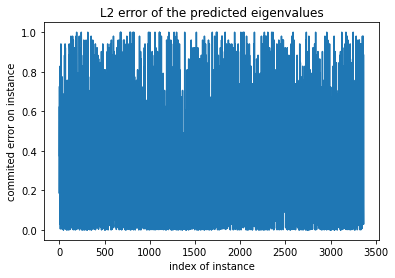

Percentage of the commited error between 0,5e-6 is: 0.83160083
Percentage of the commited error between 5e-6,5e-5 is: 0.00000000
Percentage of the commited error between 5e-5,5e-4 is: 1.98990199
Percentage of the commited error between 5e-4,5e-3 is: 6.08850609
Percentage of the commited error between 5e-3,5e-2 is: 13.98871399
Percentage of the commited error between 5e-2,5e-1 is: 48.52984853


<ipython-input-15-73365b74b684>:61: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),


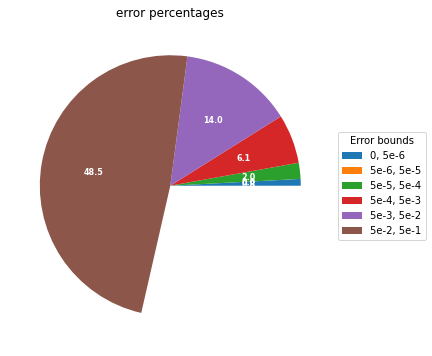

In [15]:
L2_Errors = []
for i in range(len(predicted_u[0])):
    L2_Errors.append((y_test[i] - predicted_u[0][i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

T1 = 0
T2 = 5e-6
T3 = 5e-5
T4 = 5e-4
T5 = 5e-3
T6 = 5e-2
T7 = 5e-1
S1=S2=S3=S4=S5=S6=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
print('Percentage of the commited error between 0,5e-6 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6,5e-5 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5,5e-4 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4,5e-3 is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3,5e-2 is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-2,5e-1 is: %.8f' % ((S6/len(L2_Errors)) * 100))

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors))]
ingredients = ["0, 5e-6", 
               "5e-6, 5e-5",
               "5e-5, 5e-4",
               "5e-4, 5e-3",
               "5e-3, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

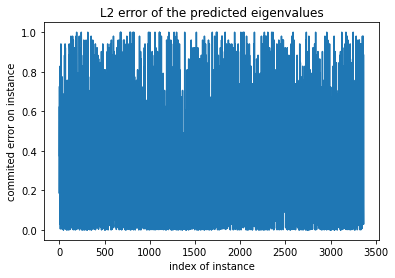

Percentage of the commited error between 0,5e-6 is: 0.83160083
Percentage of the commited error between 5e-6,5e-5 is: 0.00000000
Percentage of the commited error between 5e-5,5e-4 is: 1.98990199
Percentage of the commited error between 5e-4,5e-3 is: 6.08850609
Percentage of the commited error between 5e-3,5e-2 is: 13.98871399
Percentage of the commited error between 5e-2,5e-1 is: 48.52984853


<ipython-input-16-53880c1db7a4>:61: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),


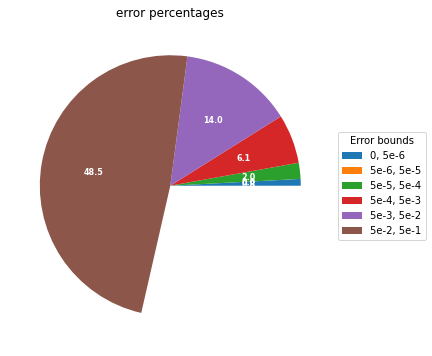

In [16]:
L2_Errors = []
for i in range(len(predicted_u[1])):
    L2_Errors.append((y_test[i] - predicted_u[1][i])**2)

import matplotlib.pyplot as plt
plt.plot(L2_Errors)
plt.title('L2 error of the predicted eigenvalues')
plt.ylabel('commited error on instance')
plt.xlabel('index of instance')
plt.show()

T1 = 0
T2 = 5e-6
T3 = 5e-5
T4 = 5e-4
T5 = 5e-3
T6 = 5e-2
T7 = 5e-1
S1=S2=S3=S4=S5=S6=0.0
for item in L2_Errors:
    if (item[0]>=T1 and item[0]< T2):
        S1 = S1 + 1
    elif (item[0]>=T2 and item[0]< T3):
        S2 = S2 + 1
    elif (item[0]>=T3 and item[0]< T4):
        S3 = S3 + 1
    elif (item[0]>=T4 and item[0]< T5):
        S4 = S4 + 1
    elif (item[0]>=T5 and item[0]< T6):
        S5 = S5 + 1
    elif (item[0]>=T6 and item[0]< T7):
        S6 = S6 + 1
print('Percentage of the commited error between 0,5e-6 is: %.8f' % ((S1/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-6,5e-5 is: %.8f' % ((S2/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-5,5e-4 is: %.8f' % ((S3/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-4,5e-3 is: %.8f' % ((S4/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-3,5e-2 is: %.8f' % ((S5/len(L2_Errors)) * 100))
print('Percentage of the commited error between 5e-2,5e-1 is: %.8f' % ((S6/len(L2_Errors)) * 100))

fig, ax = plt.subplots(figsize=(12, 6), subplot_kw=dict(aspect="equal"))


data_to_plot = [(S1/len(L2_Errors)),
          (S2/len(L2_Errors)),
          (S3/len(L2_Errors)),
          (S4/len(L2_Errors)),
          (S5/len(L2_Errors)),
          (S6/len(L2_Errors))]
ingredients = ["0, 5e-6", 
               "5e-6, 5e-5",
               "5e-5, 5e-4",
               "5e-4, 5e-3",
               "5e-3, 5e-2",
               "5e-2, 5e-1",]


def func(pct, allvals):
    return "{:.1f}".format(pct)


wedges, texts, autotexts = ax.pie(data_to_plot, autopct=lambda pct: func(pct, data_to_plot),
                                  textprops=dict(color="w"))

ax.legend(wedges, ingredients,
          title="Error bounds",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.setp(autotexts, size=8, weight="bold")

ax.set_title("error percentages")

plt.show()

In [17]:
print(history2.history.keys())

dict_keys(['loss', 'model_loss', 'grad2_loss', 'model_mae', 'grad2_mae', 'val_loss', 'val_model_loss', 'val_grad2_loss', 'val_model_mae', 'val_grad2_mae'])


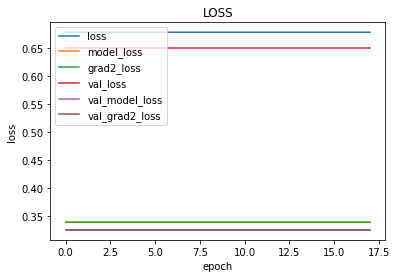

In [18]:
# summarize history for accuracy
plt.plot(history2.history['loss'])
plt.plot(history2.history['model_loss'])
plt.plot(history2.history['grad2_loss'])
plt.plot(history2.history['val_loss'])
plt.plot(history2.history['val_model_loss'])
plt.plot(history2.history['val_grad2_loss'])
plt.title('LOSS')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'model_loss', 'grad2_loss','val_loss', 'val_model_loss', 'val_grad2_loss'], loc='upper left')
#plt.show()
plt.savefig('plot1.pdf', bbox_inches='tight')

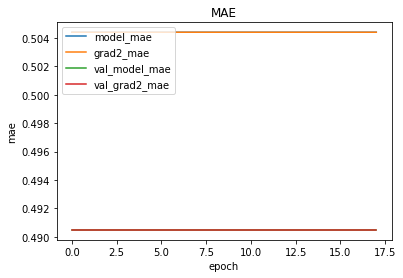

In [19]:
plt.plot(history2.history['model_mae'])
plt.plot(history2.history['grad2_mae'])
plt.plot(history2.history['val_model_mae'])
plt.plot(history2.history['val_grad2_mae'])
plt.title('MAE')
plt.ylabel('mae')
plt.xlabel('epoch')
plt.legend(['model_mae', 'grad2_mae', 'val_model_mae', 'val_grad2_mae'], loc='upper left')
#plt.show()
plt.savefig('plot2.pdf', bbox_inches='tight')

In [20]:
u

<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'dense_1')>

In [21]:
model.output

<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'dense_1')>

In [22]:
model([x,y])

<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'model')>

In [23]:
def MyModel(X):
    with tf.GradientTape() as t:
        with tf.GradientTape() as tt:
            z = model(X)
        grad = tt.gradient(z, {'x': X[1], 'y': X[2]})
    grad2 = t.gradient(grad, {'x': X[1], 'y': X[2]})
    return -1 * (grad2['x']+grad2['y'])

In [24]:
def MyLoss(X,u_0):
    u_0_pred = MyModel(X)
    u_1_pred = model(X)
    return tf.reduce_sum(tf.square(u_0_pred - u_0)) + tf.reduce_sum(tf.square(u_1_pred))

In [25]:
model2.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            [(None, 1)]          0                                            
__________________________________________________________________________________________________
model (Functional)              (None, 1)            9           input_3[0][0]                    
                                                                 input_4[0][0]                    
__________________________________________________________________________________________________
grad2 (Lambda)                  (None, 1)            0           input_3[0][0]              

In [26]:
losses ={
    u.name.split('/')[0]: ['mse'],
    'grad2': ['mse']
}
lossWeights={
    u.name.split('/')[0]: 0.5,
    'grad2': 0.5
}
custom_metrics ={
    u.name.split('/')[0]: ['mae'],
    'grad2': ['mae']
}

In [27]:
opt = optimizers.Nadam(lr=0.005, beta_1=0.9, beta_2=0.999)
model3.compile(optimizer=opt,
             loss=losses,
             loss_weights= lossWeights,
             metrics=custom_metrics
             )

NameError: name 'model3' is not defined

In [ ]:
# fitting the data with model (learning process)
history3 = model3.fit([X_train[:,0], X_train[:,1]], y_train,validation_split=0.15, epochs=50, batch_size=50, callbacks=[EarlyStoppingAtMinLoss(15)])  

In [ ]:
x = tf.Variable(np.random.normal(size=(1, 1)), dtype=tf.float32)
y = tf.Variable(np.random.normal(size=(1, 1)), dtype=tf.float32)

with tf.GradientTape() as t:
    z = model3([x,y])
grad = t.gradient(z, {'x': x, 'y': y})

with tf.GradientTape() as t:
    with tf.GradientTape() as tt:
        z = model([x,y])
    grad = tt.gradient(z, {'x': x, 'y': y})
grad2 = t.gradient(grad, {'x': x, 'y': y})
    
print('dz/dx:', grad2['x'])  # 2*x => 4
print('dz/dy:', grad2['y'])


losss = - grad['x'] * grad['y']

In [ ]:
losss

In [ ]:
model3.summary()

In [ ]:
model3.layers[4].output

In [ ]:
tf.compat.v1.disable_eager_execution()
K.gradients(model3.layers[4].output, [model3.layers[0].output, model3.layers[1].output])